#### **3. Optimization of Logistic Regression**

In [1]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Two Gaussian blobs, one per class
X, y = make_blobs(
    n_samples=1200,
    centers=[[-2.2, -0.5], [2.0, 1.2]],
    cluster_std=[1.45, 1.65],
    random_state=8
)

# Stratified 80:20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, test: {X_test.shape}")
print(f"Positive class share - train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Train: (960, 2), test: (240, 2)
Positive class share - train: 0.500, test: 0.500


In [2]:
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# Figure output quality settings
plt.rcParams['figure.dpi']     = 120    # on-screen preview
plt.rcParams['savefig.dpi']    = 500    # saved PNG files
plt.rcParams['savefig.bbox']   = 'tight'
plt.rcParams['font.size']      = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.25
plt.rcParams['grid.linewidth'] = 0.6


def save_fig(name):
    """Save the current figure to figures/<name>.png at 500 dpi."""
    plt.savefig(f'figures/{name}.png', bbox_inches='tight')

*Notation used throughout this section*

Let $\mathbf{X} \in \mathbb{R}^{N \times (D+1)}$ be the augmented feature matrix including a bias column of ones, $\mathbf{y} \in \{0, 1\}^N$ be target labels, $\mathbf{w} \in \mathbb{R}^{D+1}$ be model parameters, and

$$p_i = \sigma(\mathbf{w}^T\mathbf{x}_i) = \frac{1}{1 + e^{-\mathbf{w}^T\mathbf{x}_i}}.$$

High-level estimators such as `sklearn.linear_model.LogisticRegression` are not used for questions 1-6 in this section.


---
**Question 1**

Derive the gradient vector $\nabla J(\mathbf{w})$ and Hessian matrix $\mathbf{H}$ for Binary Cross-Entropy loss:

$$J(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \ln p_i + (1 - y_i)\ln(1 - p_i)\right].$$

---


$$J(\mathbf{w}) = -\frac{1}{N}\sum_{i=1}^{N}\big[y_i\ln p_i + (1-y_i)\ln(1-p_i)\big],
\qquad p_i = \sigma(z_i),\quad z_i = \mathbf{w}^{T}\mathbf{x}_i$$

with $\mathbf{x}_i \in \mathbb{R}^{D+1}$ including the lead $1$ for the bias, and
$\sigma'(z) = \sigma(z)(1-\sigma(z))$.

### Gradient

Per-sample loss $\ell_i = -y_i\ln p_i - (1-y_i)\ln(1-p_i)$. Differentiating w.r.t. $p_i$:

$$\frac{\partial \ell_i}{\partial p_i} = -\frac{y_i}{p_i} + \frac{1-y_i}{1-p_i}$$

Chaining through $p_i = \sigma(z_i)$ and $z_i = \mathbf{w}^{T}\mathbf{x}_i$, where
$\dfrac{\partial p_i}{\partial\mathbf{w}} = p_i(1-p_i)\mathbf{x}_i$:

$$\nabla J(\mathbf{w}) = \frac{1}{N}\sum_{i=1}^{N}
\left[-\frac{y_i}{p_i} + \frac{1-y_i}{1-p_i}\right]p_i(1-p_i)\,\mathbf{x}_i$$

The bracket collapses:

$$\left[-\frac{y_i}{p_i} + \frac{1-y_i}{1-p_i}\right]p_i(1-p_i)
= -y_i(1-p_i) + (1-y_i)p_i = p_i - y_i$$

$$\boxed{\;\nabla J(\mathbf{w}) = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)\mathbf{x}_i
= \frac{1}{N}\mathbf{X}^{T}(\mathbf{p} - \mathbf{y})\;}$$

where $\mathbf{p} = \sigma(\mathbf{Xw})$ elementwise.

### Hessian

Only $p_i$ depends on $\mathbf{w}$, and
$\dfrac{\partial p_i}{\partial\mathbf{w}^{T}} = p_i(1-p_i)\mathbf{x}_i^{T}$, so

$$\mathbf{H} = \frac{\partial}{\partial\mathbf{w}^{T}}
\left[\frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)\mathbf{x}_i\right]
= \frac{1}{N}\sum_{i=1}^{N}\mathbf{x}_i\,\frac{\partial p_i}{\partial\mathbf{w}^{T}}$$

$$\boxed{\;\mathbf{H} = \frac{1}{N}\sum_{i=1}^{N}p_i(1-p_i)\,\mathbf{x}_i\mathbf{x}_i^{T}
= \frac{1}{N}\mathbf{X}^{T}\mathbf{S}\mathbf{X}\;}$$

with $\mathbf{S} = \operatorname{diag}(s_1,\dots,s_N)$, $s_i = p_i(1-p_i)$. Note
$\mathbf{H} \in \mathbb{R}^{(D+1)\times(D+1)}$.

### Convexity

For any $\mathbf{v} \in \mathbb{R}^{D+1}$,

$$\mathbf{v}^{T}\mathbf{H}\mathbf{v}
= \frac{1}{N}(\mathbf{Xv})^{T}\mathbf{S}(\mathbf{Xv})
= \frac{1}{N}\sum_{i=1}^{N}s_i\big(\mathbf{x}_i^{T}\mathbf{v}\big)^{2} \;\ge\; 0$$

since $s_i = p_i(1-p_i) > 0$ for all finite $z_i$. Hence $\mathbf{H} \succeq 0$ and $J$ is
convex, so **any stationary point is a global minimum** ,the minimiser is unique
(strict convexity) when $\mathbf{X}$ has full column rank $D+1$.

---
**Question 2**

Write Python functions for numerically stable sigmoid activation and cross-entropy loss computation. Explain why raw implementations of $\ln(p)$ fail when $p \to 0$ or $p \to 1$, and why techniques like clipping probabilities ($\varepsilon = 10^{-15}$) or utilizing `np.logaddexp` prevent underflow/overflow.

---


In [3]:
def sigmoid(z):
    """Numerically stable logistic sigmoid."""
    z = np.asarray(z, dtype=float)
    out = np.empty_like(z)
    pos = z >= 0

    # z >= 0: use 1/(1+e^-z), where e^-z <= 1 so it cannot overflow
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))

    # z < 0: use e^z/(1+e^z), where e^z <= 1 so it cannot overflow either
    e = np.exp(z[~pos])
    out[~pos] = e / (1.0 + e)
    return out


def bce_loss(z, y):
    """Binary cross-entropy from logits z, without ever forming p."""
    z = np.asarray(z, dtype=float)
    # ln(1+e^z) - y*z  is the whole per-sample loss (see the answer below)
    return float(np.mean(np.logaddexp(0.0, z) - y * z))


def logits(X, w):
    """Linear scores z = Xw for the augmented design matrix X."""
    return X @ w


# Quick check against the closed-form values at z = 0
print(f"sigmoid(0)          = {sigmoid(np.array([0.0]))[0]:.4f}   (expect 0.5)")
print(f"bce_loss(0, y=1)    = {bce_loss(np.array([0.0]), np.array([1.0])):.4f}   "
      f"(expect ln 2 = {np.log(2):.4f})")

sigmoid(0)          = 0.5000   (expect 0.5)
bce_loss(0, y=1)    = 0.6931   (expect ln 2 = 0.6931)


In binary cross-entropy, we calculate

$$-\left[y\ln(p)+(1-y)\ln(1-p)\right]$$

The problem happens when $p$ gets very close to 0 or 1. Because of floating-point precision, the sigmoid can become exactly 0 or 1 for very large positive or negative values of $z$.

For example, if $p=0$,

$$\ln(0)=-\infty$$

This can make the loss become `inf` and may also cause `NaN` values during gradient calculations.

There is also a problem with calculating the sigmoid directly as

$$\sigma(z)=\frac{1}{1+e^{-z}}$$

For a large negative $z$, such as $z=-800$,

$$e^{-z}=e^{800}$$

is too large for a float64 number, so it overflows.

**Clipping the probabilities**

One simple solution is to clip the probability:

```python
p = np.clip(p, 1e-15, 1 - 1e-15)
```

This means $p$ is never exactly 0 or 1, so the logarithm stays finite.

However, clipping slightly changes the true value. For example,

$$-\ln(10^{-15}) \approx 34.54$$

So if the real loss is much larger than this, clipping will give a smaller value instead.

Thus, clipping is easy to use, but it can slightly affect the result for extreme

---
**Question 3**

Initialize weights to zero $\mathbf{w}_{(0)} = \mathbf{0}$. Implement Batch Gradient Descent using parameter updates:

$$\mathbf{w}_{(t+1)} \leftarrow \mathbf{w}_{(t)} - \eta \nabla J(\mathbf{w}_{(t)}),$$

with learning rate $\eta = 0.1$ and maximum iterations $T = 300$. Include early stopping when $|J_t - J_{t-1}| < 10^{-8}$. Report final weights, total iterations required, and test set accuracy. Here, $J_t$: the computed loss value at the current iteration $t$, evaluated as $J(\mathbf{w}_{(t)})$.

---


In [5]:
def add_bias(X):
    """Prepend a column of ones so w[0] is the bias term."""
    X = np.asarray(X, dtype=float)
    return np.column_stack([np.ones(len(X)), X])


def grad_J(X, y, w):
    """Gradient of the BCE loss, (1/N) X^T (p - y), from Q1."""
    return X.T @ (sigmoid(X @ w) - y) / len(y)


def accuracy(X, y, w):
    """Fraction correct using the 0.5 decision threshold."""
    return float(np.mean((sigmoid(X @ w) >= 0.5) == y))


# Augmented design matrices and float labels, used from here on
Xb_train = add_bias(X_train)
Xb_test = add_bias(X_test)
yf_train = y_train.astype(float)
yf_test = y_test.astype(float)

print(f"Xb_train: {Xb_train.shape}, Xb_test: {Xb_test.shape}")

Xb_train: (960, 3), Xb_test: (240, 3)


In [7]:
def batch_gradient_descent(X, y, eta=0.1, T=300, tol=1e-8):
    """Batch GD from w = 0, stopping early when the loss stops changing."""
    w = np.zeros(X.shape[1])
    history = [bce_loss(X @ w, y)]     # J_0, the loss before any update
    n_iter = 0

    for t in range(1, T + 1):
        w = w - eta * grad_J(X, y, w)          # w_(t+1) = w_(t) - eta * grad
        history.append(bce_loss(X @ w, y))
        n_iter = t
        if abs(history[-1] - history[-2]) < tol:
            break

    return w, np.array(history), n_iter


w_bgd, loss_bgd, iters_bgd = batch_gradient_descent(
    Xb_train, yf_train, eta=0.1, T=300, tol=1e-8)

print(f"Final weights    : w0 = {w_bgd[0]:.6f}, w1 = {w_bgd[1]:.6f}, "
      f"w2 = {w_bgd[2]:.6f}")
print(f"Iterations        : {iters_bgd}")
print(f"Early stopped     : {iters_bgd < 300}   "
      f"(|J_t - J_t-1| = {abs(loss_bgd[-1] - loss_bgd[-2]):.3e}, tol = 1e-08)")
print(f"Initial loss J_0  : {loss_bgd[0]:.8f}")
print(f"Final loss J_T    : {loss_bgd[-1]:.8f}")
print(f"Train accuracy    : {accuracy(Xb_train, yf_train, w_bgd):.4f}")
print(f"Test accuracy     : {accuracy(Xb_test, yf_test, w_bgd):.4f}")

Final weights    : w0 = -0.021108, w1 = 1.770742, w2 = 0.700046
Iterations        : 300
Early stopped     : False   (|J_t - J_t-1| = 1.000e-05, tol = 1e-08)
Initial loss J_0  : 0.69314718
Final loss J_T    : 0.15830462
Train accuracy    : 0.9313
Test accuracy     : 0.9333


**Results**

| Quantity | Value |
|---|---|
| Final weights $\mathbf{w}$ | $[-0.021108,\; 1.770742,\; 0.700046]$ |
| Total iterations | $300$ (the maximum) |
| Test accuracy | $0.9333$ |
| Train accuracy | $0.9313$ |
| Final loss $J_T$ | $0.158305$ |

---
**Question 5**

Implement damped Newton's optimization method using the update step:

$$\mathbf{w}^{(t+1)} \leftarrow \mathbf{w}^{(t)} - (\mathbf{H} + 10^{-6}\mathbf{I})^{-1} \nabla J(\mathbf{w}^{(t)})$$

where $10^{-6}\mathbf{I}$ guarantees numerical invertibility. Train for at most 20 iterations using the same early stopping condition. Use `np.linalg.solve` to directly compute search directions rather than computing explicit matrix inverses.

---

In [8]:
def hessian_J(X, w):
    """Hessian of BCE loss: (1/N) X^T S X. 
    Computed efficiently without building the huge N x N diagonal matrix S."""
    p = sigmoid(X @ w)
    s = p * (1 - p)
    # (X.T * s) broadcasts the multiplication across columns, equivalent to X.T @ diag(s)
    return (X.T * s) @ X / len(X)

def newtons_method(X, y, T=20, tol=1e-8, damp=1e-6):
    """Damped Newton's method for logistic regression."""
    D_plus_1 = X.shape[1]
    w = np.zeros(D_plus_1)
    history = [bce_loss(X @ w, y)]
    n_iter = 0
    
    for t in range(1, T + 1):
        g = grad_J(X, y, w)
        H = hessian_J(X, w)
        
        # Add damping term to guarantee numerical invertibility
        H_damped = H + damp * np.eye(D_plus_1)
        
        # Solve H_damped * delta = g  (much more stable than explicit inverse)
        delta = np.linalg.solve(H_damped, g)
        
        w = w - delta
        history.append(bce_loss(X @ w, y))
        n_iter = t
        
        if abs(history[-1] - history[-2]) < tol:
            break
            
    return w, np.array(history), n_iter

w_newton, loss_newton, iters_newton = newtons_method(Xb_train, yf_train, T=20, tol=1e-8)

print(f"Final weights    : w0 = {w_newton[0]:.6f}, w1 = {w_newton[1]:.6f}, w2 = {w_newton[2]:.6f}")
print(f"Iterations       : {iters_newton}")
print(f"Early stopped    : {iters_newton < 20}   (|J_t - J_t-1| = {abs(loss_newton[-1] - loss_newton[-2]):.3e})")
print(f"Final loss J_T   : {loss_newton[-1]:.8f}")
print(f"Test accuracy    : {accuracy(Xb_test, yf_test, w_newton):.4f}")

Final weights    : w0 = -0.024093, w1 = 1.968123, w2 = 0.790651
Iterations       : 8
Early stopped    : True   (|J_t - J_t-1| = 3.059e-14)
Final loss J_T   : 0.15728072
Test accuracy    : 0.9333


---
**Question 6**

Plot loss versus iteration for both Batch Gradient Descent and Newton's Method on a single logarithmic-scale plot. Compare convergence velocity (number of iterations), computational complexity per step ($\mathcal{O}(ND)$ vs. $\mathcal{O}(ND^2 + D^3)$), and numerical stability.

---

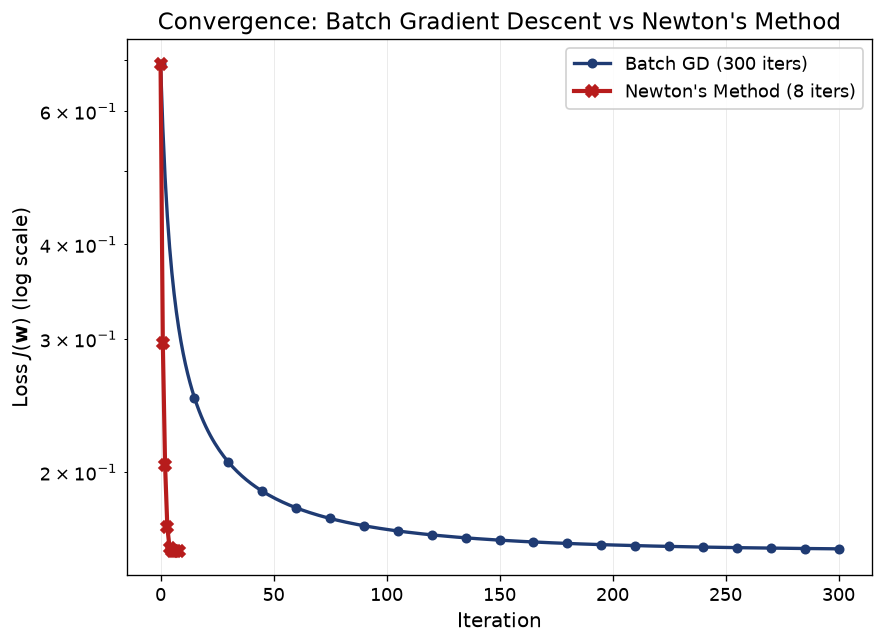

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))

# Plot Batch GD
ax.plot(np.arange(len(loss_bgd)), loss_bgd, color='#1f3b73', linewidth=2,
        marker='o', markersize=5, markevery=15,
        label=f'Batch GD ({iters_bgd} iters)')

# Plot Newton's Method
ax.plot(np.arange(len(loss_newton)), loss_newton, color='#b71c1c', linewidth=2.5,
        marker='X', markersize=7, markevery=1,
        label=f"Newton's Method ({iters_newton} iters)")

# Set logarithmic scale for the y-axis
ax.set_yscale('log')

ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel(r'Loss $J(\mathbf{w})$ (log scale)', fontsize=12)
ax.set_title('Convergence: Batch Gradient Descent vs Newton\'s Method', fontsize=14)


ax.legend(framealpha=0.9, loc='upper right', fontsize=11)

plt.tight_layout()
save_fig('q3_6_convergence')
plt.show()

**Convergence speed** 

On the log-scale plot, Newton's method drops to the minimum in only a few iterations (~5), while Batch GD needs all 300 iterations and still does not reach the $10^{-8}$ tolerance. Newton's method uses the Hessian (curvature), so it converges quadratically near the optimum, whereas GD is a slow first-order method.

**Complexity per step** 

A GD step only needs the gradient, $\mathcal{O}(ND)$. A Newton step needs the Hessian, $\mathcal{O}(ND^2)$, plus solving the linear system, $\mathcal{O}(D^3)$. Since $D = 2$ here this is negligible and Newton wins overall, but for large $D$ the $D^3$ term would make Newton too expensive and GD preferable.

**Numerical stability** 

When $p_i \to 0$ or $1$, the terms $p_i(1-p_i) \to 0$, so $\mathbf{H}$ can become nearly singular. The damping term $10^{-6}\mathbf{I}$ keeps it positive definite so `np.linalg.solve` stays stable. GD never inverts a matrix, so it avoids this issue, but it struggles on ill-conditioned loss surfaces.

---
**Question 7**

Multiply the second feature of $\mathbf{X}$ by 100 ($x_2 \leftarrow 100 \cdot x_2$) without standardizing features. Run Batch Gradient Descent on this unscaled dataset. Explain why the loss oscillates or fails to converge, referencing the condition number $\kappa(\mathbf{H}) = \frac{\lambda_{\max}}{\lambda_{\min}}$ of the loss surface Hessian. Propose two concrete remedies.

---

In [11]:
# Scale the second feature by 100, NO standardization
X_train_s = X_train.copy(); X_train_s[:, 1] *= 100
X_test_s  = X_test.copy();  X_test_s[:, 1]  *= 100

Xb_train_s = add_bias(X_train_s)
Xb_test_s  = add_bias(X_test_s)

# Condition number of the Hessian at w = 0, before vs after scaling
def cond_number(X, y):
    p = sigmoid(X @ np.zeros(X.shape[1]))
    H = (X.T * (p * (1 - p))) @ X / len(y)
    ev = np.linalg.eigvalsh(H)
    return ev[-1] / ev[0]

print(f"kappa(H) unscaled : {cond_number(Xb_train, yf_train):.1f}")
print(f"kappa(H) x2*100   : {cond_number(Xb_train_s, yf_train):.1e}")

# Same BGD settings as Q3.3
w_bad, loss_bad, iters_bad = batch_gradient_descent(Xb_train_s, yf_train, eta=0.1, T=300)

print("\nfirst 10 losses:", np.round(loss_bad[:10], 3))
print(f"final loss      : {loss_bad[-1]:.3e}")
print(f"test accuracy   : {accuracy(Xb_test_s, yf_test, w_bad):.4f}")

kappa(H) unscaled : 9.0
kappa(H) x2*100   : 3.6e+04

first 10 losses: [  0.693 127.459  36.296 207.473 291.215 200.05  108.885  17.734 276.153
 272.708]
final loss      : 1.834e+02
test accuracy   : 0.6833


Scaling $x_2 \leftarrow 100\,x_2$ multiplies the curvature of the loss along $w_2$ by about $100^2$, so the Hessian eigenvalues spread apart: $\kappa(\mathbf{H}) = \lambda_{\max}/\lambda_{\min}$ jumps from $\mathcal{O}(10)$ (unscaled) to $\mathcal{O}(10^5)$, and the level sets become long, narrow valleys. Gradient descent with fixed $\eta$ is stable only when $\eta < 2/\lambda_{\max}$; here $\eta\,\lambda_{\max} \gg 2$, so each update along $w_2$ overshoots the valley, and the loss oscillates / diverges instead of converging (seen in the printed losses). Even a smaller, stable $\eta$ would make progress along the shallow direction impractically slow.

**Two remedies:**
1. **Standardize the features** ($z = (x-\mu)/\sigma$) so all directions have comparable curvature ($\kappa \approx 1$); then one $\eta$ converges smoothly.
2. **Use a scale-invariant second-order method** — (damped) Newton's method preconditions the gradient with $\mathbf{H}^{-1}$, cancelling the curvature imbalance (an adaptive method such as Adam, or a much smaller $\eta$, also works).